In [2]:
import pandas as pd

In [15]:
df = pd.read_csv("dataset.csv")

In [16]:
queries = df['query'].values
labels = df['label'].values

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(
    queries,
    labels,
    test_size=0.3,
    stratify=labels,
    random_state=42
)

In [20]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [22]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10000,
        lowercase=True,
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

In [24]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_val_pred = pipeline.predict(X_val)

print(classification_report(y_val, y_val_pred))
print(confusion_matrix(y_val, y_val_pred))

              precision    recall  f1-score   support

         llm       0.82      0.96      0.88        55
      search       0.96      0.81      0.88        62

    accuracy                           0.88       117
   macro avg       0.89      0.89      0.88       117
weighted avg       0.89      0.88      0.88       117

[[53  2]
 [12 50]]


In [27]:
y_test_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_test_pred))
print(confusion_matrix(y_test, y_test_pred))

              precision    recall  f1-score   support

         llm       0.89      0.96      0.92        56
      search       0.96      0.89      0.92        62

    accuracy                           0.92       118
   macro avg       0.93      0.93      0.92       118
weighted avg       0.93      0.92      0.92       118

[[54  2]
 [ 7 55]]


In [28]:
probs = pipeline.predict_proba(X_test)
max_probs = probs.max(axis=1)

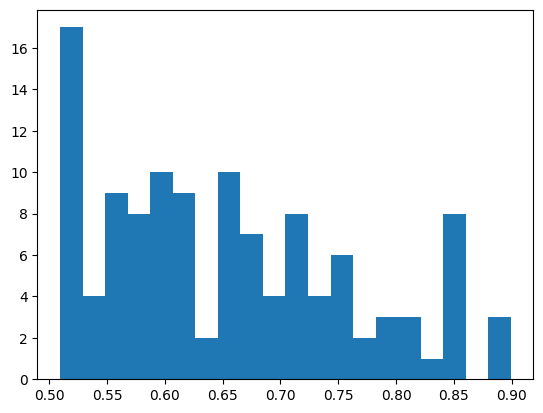

In [29]:
import matplotlib.pyplot as plt
plt.hist(max_probs, bins=20)
plt.show()

In [30]:
import numpy as np

In [42]:
def route_query(query, model, threshold=0.65):
    """
    Returns:
        label: 'search', 'llm', or 'uncertain'
        confidence: probability of chosen class
        probabilities: full class probability dict
    """
    
    probs = model.predict_proba([query])[0]
    classes = model.classes_
    
    max_idx = np.argmax(probs)
    max_prob = probs[max_idx]
    predicted_label = classes[max_idx]
    
    prob_dict = dict(zip(classes, probs))
    
    # if max_prob < threshold:
    #     return "search", max_prob, prob_dict # if unsure, default to search first to reduce unnecessary llm usage and save energy.
    
    return predicted_label, max_prob, prob_dict

In [43]:
label, confidence, probs = route_query(
    "gordon ramsay level eggs boiled",
    pipeline,
    threshold=0.70
)

print("Prediction:", label)
print("Confidence:", round(confidence, 3))
print("Probabilities:", probs)

Prediction: llm
Confidence: 0.511
Probabilities: {'llm': 0.5107661928935813, 'search': 0.4892338071064187}


In [45]:
import pickle

with open("query_router.pkl", "wb") as f:
    pickle.dump(pipeline, f)

print("Model saved successfully.")

Model saved successfully.


In [46]:
def load_model():
  import pickle

  with open("query_router.pkl", "rb") as f:
      loaded_model = pickle.load(f)

  print("Model loaded.")